# Embedding Creation and Distance Calculation

## Embeddings

### Download model and clear cache

In [ ]:
import os
import pickle
import json
from sentence_transformers import SentenceTransformer

pasta_modelo_local = "../all_mpnet_base_v2"

print("🧠 Carregando o modelo diretamente do disco local...")
model = SentenceTransformer(pasta_modelo_local)
print("✅ Modelo carregado com sucesso!")

def processar_e_salvar_embeddings(arquivo_json, arquivo_cache):
    if os.path.exists(arquivo_cache):
        print(f"📦 Carregando cache local: {arquivo_cache}")
        with open(arquivo_cache, 'rb') as f:
            return pickle.load(f)
    
    print(f"🚀 Gerando matriz para: {arquivo_json}")
    with open(arquivo_json, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    ids = list(data.keys())
    textos = list(data.values())
    
    embeddings = model.encode(textos, show_progress_bar=True)
    
    cache_data = {ids[i]: embeddings[i] for i in range(len(ids))}
    
    diretorio = os.path.dirname(arquivo_cache)
    if diretorio:
        os.makedirs(diretorio, exist_ok=True)
    
    with open(arquivo_cache, 'wb') as f:
        pickle.dump(cache_data, f)
    
    print(f"✅ Arquivo salvo com sucesso em: {arquivo_cache}")
    return cache_data

🧠 Carregando o modelo diretamente do disco local...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Modelo carregado com sucesso!


In [6]:
# Mapeamento do Hadolint + ShellCheck
hadolint_embeddings = processar_e_salvar_embeddings(
    '../data/output/datasets/hadolint_rules.json', 
    '../data/output/embeddings/cache_hadolint.pkl'
)

🚀 Gerando matriz para: ../data/output/datasets/hadolint_rules.json


Batches:   0%|          | 0/19 [00:00<?, ?it/s]

✅ Arquivo salvo com sucesso em: ../data/output/embeddings/cache_hadolint.pkl


In [7]:
# 1. CIS Docker Benchmark
cis_embeddings = processar_e_salvar_embeddings(
    '../data/output/datasets/cis_docker_benchmark.json', 
    '../data/output/embeddings/cache_cis.pkl'
)

🚀 Gerando matriz para: ../data/output/datasets/cis_docker_benchmark.json


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Arquivo salvo com sucesso em: ../data/output/embeddings/cache_cis.pkl


In [8]:
# 2. CWE (Common Weakness Enumeration)
cwe_embeddings = processar_e_salvar_embeddings(
    '../data/output/datasets/cwe.json', 
    '../data/output/embeddings/cache_cwe.pkl'
)

🚀 Gerando matriz para: ../data/output/datasets/cwe.json


Batches:   0%|          | 0/31 [00:00<?, ?it/s]

✅ Arquivo salvo com sucesso em: ../data/output/embeddings/cache_cwe.pkl


In [9]:
# 3. IEC 62443 (Automação Industrial)
iec_embeddings = processar_e_salvar_embeddings(
    '../data/output/datasets/iec62443.json', 
    '../data/output/embeddings/cache_iec.pkl'
)

🚀 Gerando matriz para: ../data/output/datasets/iec62443.json


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Arquivo salvo com sucesso em: ../data/output/embeddings/cache_iec.pkl


## Calculating the best power

📦 Carregando vetores de todas as normas...
🧮 Calculando matrizes base de Similaridade de Cosseno...
⚙️ Iterando potências de 1 a 20 para os três frameworks...
📊 Gerando o gráfico comparativo...
✅ Gráfico 'grafico_potencia_multiplo.png' salvo com sucesso!


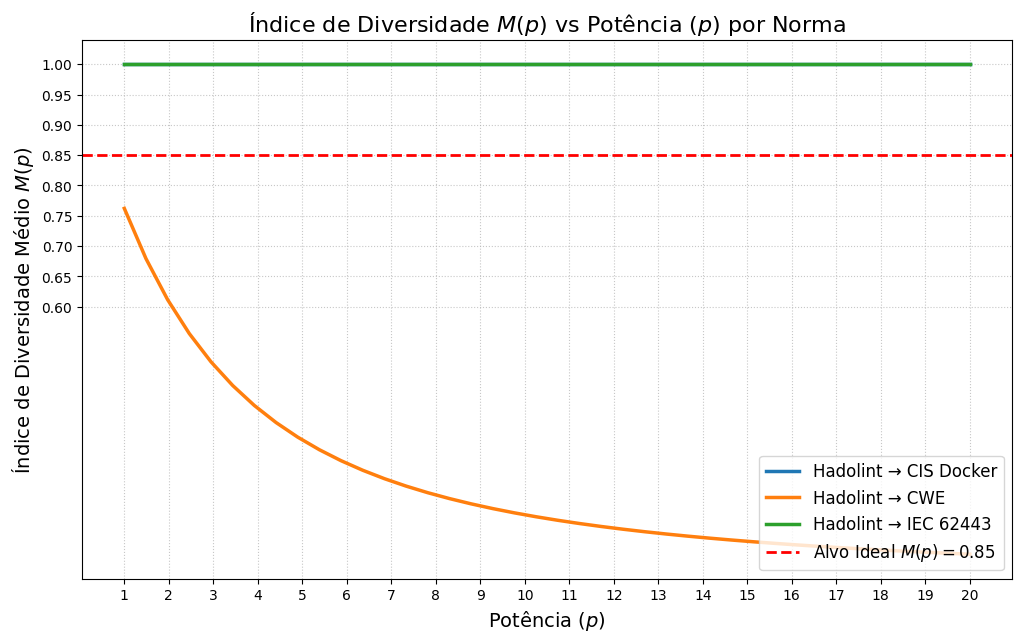

In [18]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import pickle
from sentence_transformers import util

def carregar_cache(caminho):
    with open(caminho, 'rb') as f:
        return pickle.load(f)

print("📦 Carregando vetores de todas as normas...")
hadolint_cache = carregar_cache('../data/output/embeddings/cache_hadolint.pkl')
cis_cache = carregar_cache('../data/output/embeddings/cache_cis.pkl')
cwe_cache = carregar_cache('../data/output/embeddings/cache_cwe.pkl')
iec_cache = carregar_cache('../data/output/embeddings/cache_iec.pkl')

vetores_origem = torch.stack([torch.tensor(v) for v in hadolint_cache.values()])
vetores_cis = torch.stack([torch.tensor(v) for v in cis_cache.values()])
vetores_cwe = torch.stack([torch.tensor(v) for v in cwe_cache.values()])
vetores_iec = torch.stack([torch.tensor(v) for v in iec_cache.values()])

# Função para calcular a matriz base zerando negativos
def calcular_matriz_base(origem, alvo):
    matriz = util.cos_sim(origem, alvo)
    return torch.clamp(matriz, min=0.0)

print("🧮 Calculando matrizes base de Similaridade de Cosseno...")
matriz_cis = calcular_matriz_base(vetores_origem, vetores_cis)
matriz_cwe = calcular_matriz_base(vetores_origem, vetores_cwe)
matriz_iec = calcular_matriz_base(vetores_origem, vetores_iec)

def calcular_Mp(matriz_base, p):
    matriz_pow = torch.pow(matriz_base, p)
    maximos_por_linha = torch.max(matriz_pow, dim=1, keepdim=True)[0]
    maximos_por_linha[maximos_por_linha == 0] = 1.0 
    matriz_norm = matriz_pow / maximos_por_linha
    maximos_por_coluna = torch.max(matriz_norm, dim=0)[0]
    return torch.mean(maximos_por_coluna).item()

valores_p = np.linspace(1, 20, 40)
Mp_cis, Mp_cwe, Mp_iec = [], [], []

print("⚙️ Iterando potências de 1 a 20 para os três frameworks...")
for p in valores_p:
    Mp_cis.append(calcular_Mp(matriz_cis, p))
    Mp_cwe.append(calcular_Mp(matriz_cwe, p))
    Mp_iec.append(calcular_Mp(matriz_iec, p))

print("📊 Gerando o gráfico comparativo...")
plt.figure(figsize=(12, 7))

# Plota as três linhas com cores distintas
plt.plot(valores_p, Mp_cis, label='Hadolint → CIS Docker', color='#1f77b4', linewidth=2.5)
plt.plot(valores_p, Mp_cwe, label='Hadolint → CWE', color='#ff7f0e', linewidth=2.5)
plt.plot(valores_p, Mp_iec, label='Hadolint → IEC 62443', color='#2ca02c', linewidth=2.5)

# Linha do Alvo
plt.axhline(y=0.85, color='red', linestyle='--', label='Alvo Ideal $M(p) = 0.85$', linewidth=2)

# Estética
plt.title("Índice de Diversidade $M(p)$ vs Potência ($p$) por Norma", fontsize=16)
plt.xlabel("Potência ($p$)", fontsize=14)
plt.ylabel("Índice de Diversidade Médio $M(p)$", fontsize=14)
plt.xticks(np.arange(1, 21, 1))
plt.yticks(np.arange(0.60, 1.01, 0.05))
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12, loc='lower right')

arquivo = "../data/output/images/grafico_potencia_multiplo.png"
diretorio = os.path.dirname(arquivo)
if diretorio:
    os.makedirs(diretorio, exist_ok=True)

# Exporta
plt.savefig(arquivo, dpi=300, bbox_inches='tight')
print("✅ Gráfico 'grafico_potencia_multiplo.png' salvo com sucesso!")
plt.show()

## Distance Calculation

In [13]:
import json
import pickle
import torch
from sentence_transformers import util

def carregar_cache(caminho_arquivo):
    with open(caminho_arquivo, 'rb') as f:
        return pickle.load(f)

print("📦 Carregando os vetores da memória...")
hadolint_cache = carregar_cache('../data/output/embeddings/cache_hadolint.pkl')
cis_cache = carregar_cache('../data/output/embeddings/cache_cis.pkl')
cwe_cache = carregar_cache('../data/output/embeddings/cache_cwe.pkl')
iec_cache = carregar_cache('../data/output/embeddings/cache_iec.pkl')

def buscar_matches(vetor_origem, dicionario_alvo, top_k=10, p=5.5):
    """
    Implementa a metodologia do artigo:
    1. Calcula Cosine Similarity
    2. Aplica potência p=5.5
    3. Normaliza por L_infinity (Max Score = 1.0)
    """
    ids_alvo = list(dicionario_alvo.keys())
    vetores_alvo = torch.stack([torch.tensor(v) for v in dicionario_alvo.values()])
    vetor_origem_tensor = torch.tensor(vetor_origem).unsqueeze(0)
    
    # 1. Similaridade Bruta de Cosseno
    raw_scores = util.cos_sim(vetor_origem_tensor, vetores_alvo)[0]
    
    # Zera scores negativos (cossenos apontando para direções opostas) para evitar bugs com potências fracionárias
    raw_scores = torch.clamp(raw_scores, min=0.0)
    
    # 2. Amplificação por Potência (Power-based transformation do Artigo)
    power_scores = torch.pow(raw_scores, p)
    
    # 3. Normalização L_infinity (Divide pelo score máximo)
    max_score = torch.max(power_scores)
    
    # Previne divisão por zero se o vetor for absolutamente não relacionado a nada (raro)
    if max_score > 0:
        normalized_scores = power_scores / max_score
    else:
        normalized_scores = power_scores
        
    # 4. Seleção Top K (O artigo usa K=10, mas vamos manter seu controle de qualidade pegando os melhores)
    top_resultados = torch.topk(normalized_scores, k=min(top_k, len(ids_alvo)))
    
    matches = []
    for score, idx in zip(top_resultados[0], top_resultados[1]):
        matches.append({
            "id_alvo": ids_alvo[idx],
            "score_relativo": round(float(score), 4) # Agora representa a força em relação ao melhor match!
        })
    return matches

print("🧠 Calculando a matriz com Transfer Learning (L-infinity & Amplificação)...")
relatorio_completo = {}

for id_origem, vetor_origem in hadolint_cache.items():
    # Passamos o Top-10 para ter uma amostra profunda antes de filtrar, como no artigo
    relatorio_completo[id_origem] = {
        "mapeamento_cis": buscar_matches(vetor_origem, cis_cache, top_k=10),
        "mapeamento_cwe": buscar_matches(vetor_origem, cwe_cache, top_k=10),
        "mapeamento_iec": buscar_matches(vetor_origem, iec_cache, top_k=10)
    }

# 1. Salva o JSON com TUDO (Sua base de consulta)
with open('../data/output/mappings/mapeamento_completo.json', 'w', encoding='utf-8') as f:
    json.dump(relatorio_completo, f, indent=4)
print("✅ Salvo: mapeamento_completo.json")

# 2. Rotina de filtragem e estratificação
limiares = [0.60, 0.70, 0.80, 0.90]

print("\n📊 Gerando relatórios estratificados por confiança...")

for limiar in limiares:
    relatorio_filtrado = {}
    
    for id_origem, normas in relatorio_completo.items():
        # Filtra os arrays mantendo apenas os scores que atingem o limiar
        cis_ok = [m for m in normas["mapeamento_cis"] if m["score_relativo"] >= limiar]
        cwe_ok = [m for m in normas["mapeamento_cwe"] if m["score_relativo"] >= limiar]
        iec_ok = [m for m in normas["mapeamento_iec"] if m["score_relativo"] >= limiar]
        
        # Só insere no JSON se a regra do Hadolint conseguiu pelo menos UM match válido
        if cis_ok or cwe_ok or iec_ok:
            relatorio_filtrado[id_origem] = {
                "mapeamento_cis": cis_ok,
                "mapeamento_cwe": cwe_ok,
                "mapeamento_iec": iec_ok
            }
            
    # Formata o nome do arquivo (ex: mapeamento_acima_60.json)
    nome_arquivo = f'../data/output/mappings/mapeamento_acima_{int(limiar * 100)}.json'
    
    diretorio = os.path.dirname(nome_arquivo)
    if diretorio:
        os.makedirs(diretorio, exist_ok=True)

    with open(nome_arquivo, 'w', encoding='utf-8') as f:
        json.dump(relatorio_filtrado, f, indent=4)
        
    print(f"   🎯 {nome_arquivo} -> Retornou {len(relatorio_filtrado)} regras aprovadas.")

print("\n🚀 Execução 100% Finalizada! Todos os artefatos do TCC foram gerados no disco.")

📦 Carregando os vetores da memória...
🧠 Calculando a matriz com Transfer Learning (L-infinity & Amplificação)...
✅ Salvo: mapeamento_completo.json

📊 Gerando relatórios estratificados por confiança...
   🎯 ../data/output/mappings/mapeamento_acima_60.json -> Retornou 589 regras aprovadas.
   🎯 ../data/output/mappings/mapeamento_acima_70.json -> Retornou 589 regras aprovadas.
   🎯 ../data/output/mappings/mapeamento_acima_80.json -> Retornou 589 regras aprovadas.
   🎯 ../data/output/mappings/mapeamento_acima_90.json -> Retornou 589 regras aprovadas.

🚀 Execução 100% Finalizada! Todos os artefatos do TCC foram gerados no disco.
